## 1. Data Loading and Exploration

### 1.1 Modules and Libraries

In [1]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


### 1.2 Numerical Parameters

In [2]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

### 1.3 Simulation Parameters

In [3]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting

# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

### 1.4 Data Sources

In [4]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

## 3. Simulation

### 3.3 Optimazed Simulation with

### 3.4 Optimization - Simulation Function (PyTorch)

#### 3.4.1 Simulation Function (PyTorch)


In [5]:
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks
import statsmodels.api as sm

def run_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau, Ptotal = 0.005, 0.75, 500.0
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = Ptotal * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    scaler = MinMaxScaler()
    Rj_scaled = scaler.fit_transform(Rj_t.reshape(-1, 1)).flatten()

    # Preparar los datos
    x = np.arange(len(Rj_scaled))
    y = Rj_scaled

    # Detectar picos en los datos originales
    peaks, _ = find_peaks(y, prominence=0.1)
    peaks = np.insert(peaks, 0, 0)
    peaks = np.append(peaks, len(y)-1)

    # Filtrar los valores de los picos
    x_peaks = x[peaks]
    y_peaks = y[peaks]

    # Lowess
    lowess = sm.nonparametric.lowess(y_peaks, x_peaks, frac=0.1)
    lowess_x = lowess[:, 0]
    lowess_y = lowess[:, 1]

    # El resultado de LOWESS solo tiene puntos en los picos. Para una comparación
    # justa, lo interpolamos para que tenga la misma longitud que los datos reales.
    lowess_full_curve = np.interp(x, lowess_x, lowess_y)

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return lowess_full_curve

#### 3.4.2 Test Function Results

In [6]:
Rj_fn = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

Starting loop ...
Total execution time:  3.3309926986694336


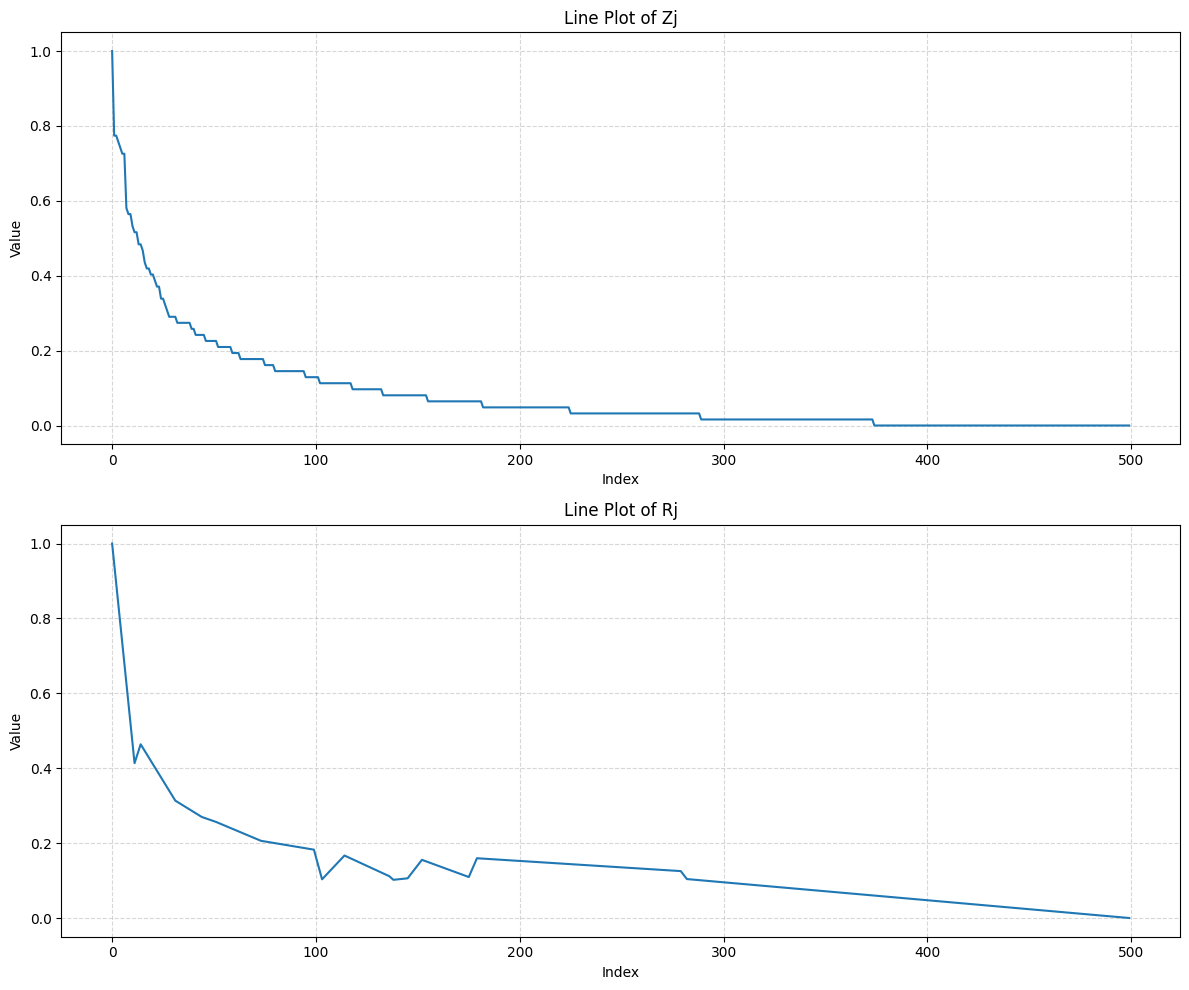

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Escalar objetivo
scaler = MinMaxScaler()
scaled_targets = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten() # (500, 1)

# Crear una figura con dos subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Primer subplot para Zj
x1 = np.arange(len(scaled_targets))
y1 = scaled_targets
ax1.plot(x1, y1)
ax1.set_xlabel('Index')
ax1.set_ylabel('Value')
ax1.set_title('Line Plot of Zj')
ax1.grid(True, linestyle='--', alpha=0.5)

# Segundo subplot para Rj
x2 = np.arange(len(Rj_fn))
y2 = Rj_fn
ax2.plot(x2, y2)
ax2.set_xlabel('Index')
ax2.set_ylabel('Value')
ax2.set_title('Line Plot of Rj')
ax2.grid(True, linestyle='--', alpha=0.5)

# Ajustar el espaciado entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

#### 3.4.3 Differential Evolution (DE)

In [8]:
import numpy as np
import time # <--- AÑADIDO: Importar el módulo time
from scipy.optimize import differential_evolution
from sklearn.preprocessing import MinMaxScaler

# Escalar objetivo
scaler = MinMaxScaler()
scaled_targets = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten() # (500, 1)

def objective_function(params, dij, Ii, Zj, target_results):
    beta_r, gamma_r, alpha_p, gamma_p = params
    # Simulación con parámetros actuales
    simulation_results = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)
    # Evaluación de la diferencia
    error = np.linalg.norm(simulation_results - target_results)
    # El print dentro de la función objetivo puede ralentizar mucho el proceso,
    # se recomienda comentarlo o eliminarlo en la ejecución final.
    print(f"DE - Error: {error}\n, Params: {params}")
    return error

# Límites de búsqueda para cada parámetro
bounds = [(0.05, 0.15),      # beta_r
          (0.15, 0.25),    # gamma_r
          (0.05, 1.5),      # alpha_p
          (0.01, 0.05)]  # gamma_p

# --- INICIO DE LA MEDICIÓN ---
print("Iniciando optimización con Differential Evolution...")
start_time = time.time() # <--- AÑADIDO: Guardar el tiempo de inicio

# Optimización con DE
result_de = differential_evolution(
    objective_function, bounds, args=(dij, Ii, Zj, scaled_targets),
    strategy='best1bin', popsize=10, tol=1e-6, disp=True, maxiter=10
)

end_time = time.time() # <--- AÑADIDO: Guardar el tiempo de finalización
# --- FIN DE LA MEDICIÓN ---

# --- CÁLCULO Y REPORTE DE RESULTADOS ---
execution_time = end_time - start_time # <--- AÑADIDO: Calcular la duración

print("\n-----------------------------------------")
print("        Resultados de la Optimización")
print("-----------------------------------------")
print(f"Parámetros óptimos encontrados: {result_de.x}")
print(f"Error final (función objetivo): {result_de.fun:.6f}")

# --- AÑADIDO: Imprimir las nuevas métricas ---
print(f"Número total de iteraciones (generaciones): {result_de.nit}")
print(f"Número total de evaluaciones de la función: {result_de.nfev}")
print(f"Tiempo total de ejecución: {execution_time:.2f} segundos")
print("-----------------------------------------")

Iniciando optimización con Differential Evolution...
Starting loop ...
Total execution time:  3.4134714603424072
DE - Error: 1.0019718487698934
, Params: [0.08309155 0.22813774 1.04310336 0.01211529]
Starting loop ...
Total execution time:  3.3494651317596436
DE - Error: 0.8537398797323352
, Params: [0.066356   0.17737221 0.59938026 0.02098469]
Starting loop ...
Total execution time:  3.342646360397339
DE - Error: 7.0488761377817255
, Params: [0.08650848 0.21121974 1.2948735  0.03686667]
Starting loop ...
Total execution time:  3.3350322246551514
DE - Error: 1.155928124024556
, Params: [0.07357784 0.15427574 0.69672694 0.0423746 ]
Starting loop ...
Total execution time:  3.3445253372192383
DE - Error: 4.46170369229919
, Params: [0.05667692 0.16354174 1.45232629 0.01663675]
Starting loop ...
Total execution time:  3.3612875938415527
DE - Error: 0.9459189882243482
, Params: [0.12883387 0.18114031 0.44013671 0.0242276 ]
Starting loop ...
Total execution time:  3.325394630432129
DE - Error

##### 3.4.3.1 Results DE

In [9]:
"""
-----------------------------------------
        Resultados de la Optimización
-----------------------------------------
Parámetros óptimos encontrados: [0.40076787 0.11035879 1.08637869 0.0093413 ]
Error final (función objetivo): 1.214961
Número total de iteraciones (generaciones): 10
Número total de evaluaciones de la función: 1655
Tiempo total de ejecución: 5867.05 segundos
-----------------------------------------"""

'\n-----------------------------------------\n        Resultados de la Optimización\n-----------------------------------------\nParámetros óptimos encontrados: [0.40076787 0.11035879 1.08637869 0.0093413 ]\nError final (función objetivo): 1.214961\nNúmero total de iteraciones (generaciones): 10\nNúmero total de evaluaciones de la función: 1655\nTiempo total de ejecución: 5867.05 segundos\n-----------------------------------------'

In [10]:
"""Parámetros óptimos encontrados: [0.47108448 0.12997733 0.92481787 0.00801267]
Error final: 0.9721194344186127"""

'Parámetros óptimos encontrados: [0.47108448 0.12997733 0.92481787 0.00801267]\nError final: 0.9721194344186127'

In [11]:
"""Stopping search: Swarm best objective change less than 1e-08
Parámetros óptimos encontrados: [0.1        0.19482765 0.97356374 0.03415131]
Error final: 0.24425217952019052"""

'Stopping search: Swarm best objective change less than 1e-08\nParámetros óptimos encontrados: [0.1        0.19482765 0.97356374 0.03415131]\nError final: 0.24425217952019052'

# Resultados

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_errors_sklearn(predicted, real):

    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

def print_detailed_comparison_sklearn(predicted, real):
    metrics = calculate_errors_sklearn(predicted, real)

    print("Métricas de error:")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"Error máximo: {metrics['max_error']:.4f}")

In [13]:
def plot_results(Zj, Rj, algorithm):

    # Crear una figura con dos subplots verticales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Agregar un título general
    fig.suptitle(f"Comparison of Riot Targets: Simulation {algorithm} vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

    # Primer subplot para Zj
    x1 = np.arange(len(Zj))
    y1 = Zj
    ax1.plot(x1, y1)
    ax1.set_xlabel('Target Points')
    ax1.set_ylabel('Rioters')
    ax1.set_title('Line Plot of Zj')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Segundo subplot para Rj
    x2 = np.arange(len(Rj))
    y2 = Rj
    ax2.plot(x2, y2)
    ax2.set_xlabel('Target Points')
    ax2.set_ylabel('Rioters')
    ax2.set_title('Line Plot of Rj')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()

In [14]:
rioters_de = run_simulation(dij, Ii, Zj, result_de.x[0], result_de.x[1], result_de.x[2], result_de.x[3])

Starting loop ...
Total execution time:  3.370877742767334


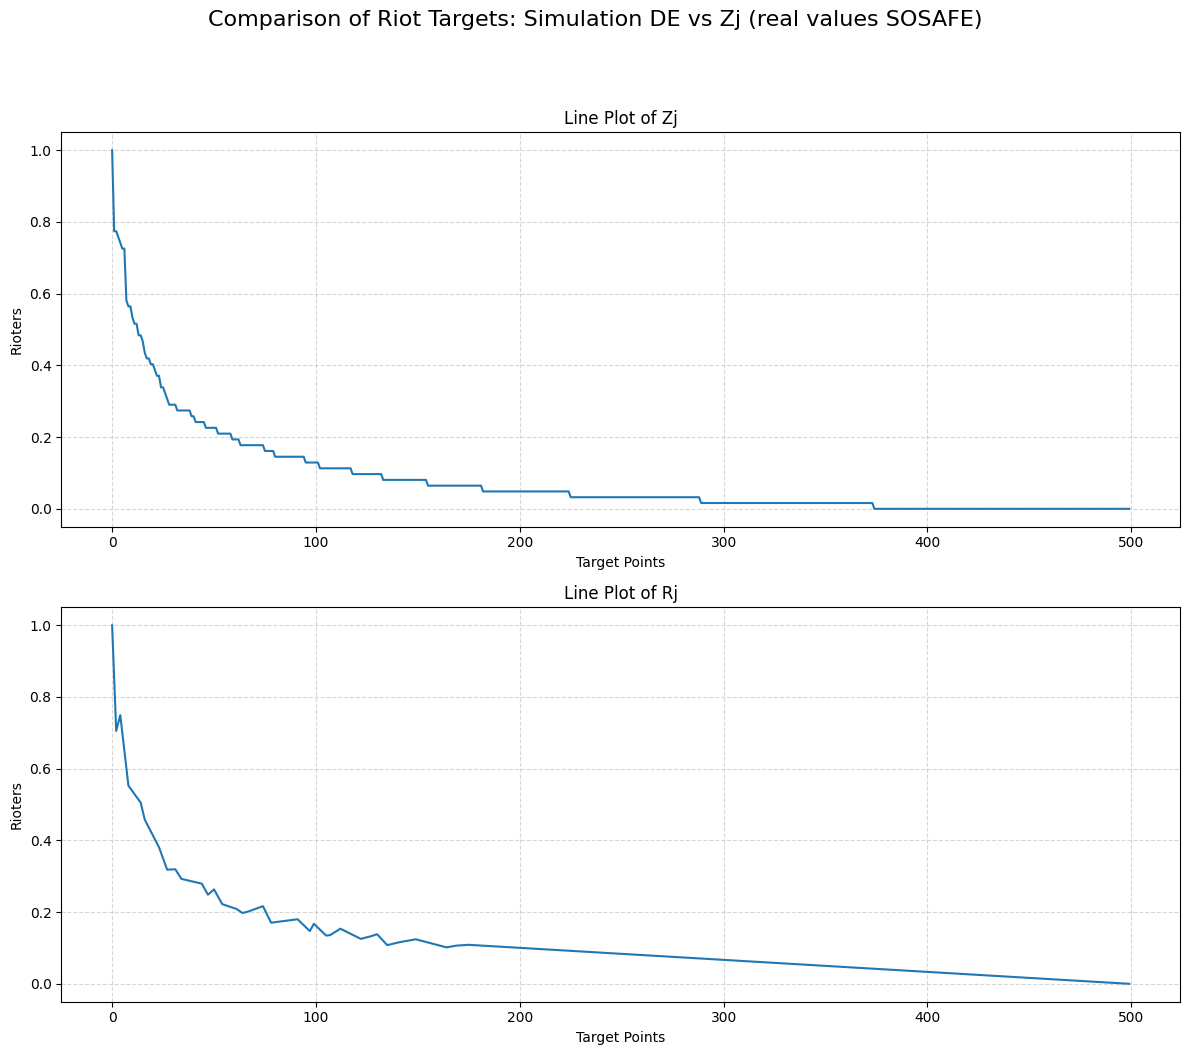

In [15]:
plot_results(scaled_targets, rioters_de, "DE")

In [16]:
print_detailed_comparison_sklearn(rioters_de, scaled_targets)

Métricas de error:
RMSE: 0.0369
MAE: 0.0339
R² Score: 0.9236
Error máximo: 0.0784
